# Labelling Evaluation Part of the Dataset

Using the trained encoder (char2pinyin), the notebook labels the second part of the target dataset for evaluation purposes

# Load Original Dataset

In [1]:
import pandas as pd

dataset = pd.read_csv("/kaggle/input/notebooks/davidvista/pinyin-dataset-labelling/chinese-short-sentences-pinyin.csv")

In [2]:
dataset.head()

,text,pinyin
0,一个特殊群体的期待在密切关注此次特金会的人中有一个特殊的群体在日本殖民期间来到日本的韩国朝鲜...,yi1 ge4 te4 shu1 qun2 ti3 de qi1 dai4 zai4 mi4...
1,他们希望政治解冻有助于让朝鲜摆脱孤立,ta1 men xi1 wang4 zheng4 zhi4 jie3 dong4 you3 ...
2,他认为对这个奖的妄想可能会促使双方做出轻率的承诺但也可能有助于艰巨的和平进程,ta1 ren4 wei2 dui4 zhe4 ge4 jiang3 de wang4 xi...
3,欢迎阅读纪思道文章的中文版,huan1 ying2 yue4 du2 ji4 si1 dao4 wen2 zhang1 ...
4,不法业者向一些中国女性编造了一个美好的未来到美国开始新生活并拥有一份合法的工作,bu4 fa3 ye4 zhe3 xiang4 yi1 xie1 zhong1 guo2 n...


In [3]:
# Build character and pinyin vocabularies from the dataset

from tqdm import tqdm

def build_vocab(dataset):
    """
    dataset: list of dicts with keys 'text' (str) and 'pinyin' (str)
    returns:
        char2idx, idx2char, pinyin2idx, idx2pinyin
    """
    # Collect all characters and pinyin tokens
    chars = set()
    pinyins = set()
    
    for i, sample in tqdm(dataset.iterrows(), total=len(dataset)):
        text = sample['text']
        pinyin_str = sample['pinyin']
        
        # Add each character from text
        for ch in text:
            chars.add(ch)
        
        # Split pinyin by space and add each token
        tokens = pinyin_str.split()
        for tok in tokens:
            pinyins.add(tok)
    
    # Convert to sorted lists for deterministic order (optional)
    char_list = ['<UNK>', '<PAD>'] + sorted(chars)
    pinyin_list = ['<UNK>', '<PAD>'] + sorted(pinyins)
    
    # Create mappings
    char2idx = {ch: idx for idx, ch in enumerate(char_list)}
    idx2char = {idx: ch for idx, ch in enumerate(char_list)}
    
    pinyin2idx = {p: idx for idx, p in enumerate(pinyin_list)}
    idx2pinyin = {idx: p for idx, p in enumerate(pinyin_list)}
    
    print(f"Number of unique characters (including specials): {len(char_list)}")
    print(f"Number of unique pinyin tokens (including specials): {len(pinyin_list)}")

    return char2idx, idx2char, pinyin2idx, idx2pinyin

In [4]:
char2idx, idx2char, pinyin2idx, idx2pinyin = build_vocab(dataset)

100%|██████████| 161521/161521 [00:08<00:00, 20138.29it/s]

Number of unique characters (including specials): 5495
Number of unique pinyin tokens (including specials): 1105


In [5]:
# Convert text and pinyin to index sequences, filtering invalid pinyin

def preprocess_dataset(dataset, char2idx, pinyin2idx):
    skipped = 0
    total = 0
    
    for i, sample in tqdm(dataset.iterrows(), total=len(dataset)):
        total += 1
        text = sample['text']
        pinyin_str = sample['pinyin']
        
        chars = list(text)
        pinyin_tokens = pinyin_str.split()
        
        # Skip if lengths don't match
        if len(chars) != len(pinyin_tokens):
            skipped += 1
            continue
        
        # Skip if any invalid pinyin token
        if any(tok not in pinyin2idx for tok in pinyin_tokens):
            skipped += 1
            continue
        
        # Valid sample - yield the indices
        char_idxs = [char2idx.get(ch, 0) for ch in chars]
        pinyin_idxs = [pinyin2idx[tok] for tok in pinyin_tokens]
        
        yield char_idxs, pinyin_idxs
    
    print(f"Processed {total} samples, skipped {skipped} with invalid pinyin")

In [6]:
preprocessed_dataset = preprocess_dataset(dataset, char2idx, pinyin2idx)

In [7]:
text_seqs = []
pinyin_seqs = []

for char_idxs, pinyin_idxs in preprocessed_dataset:
    text_seqs.append(char_idxs)
    pinyin_seqs.append(pinyin_idxs)

100%|██████████| 161521/161521 [00:10<00:00, 15669.96it/s]

Processed 161521 samples, skipped 0 with invalid pinyin


# Define BiLSTM Seq2Seq Model

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BiLSTMForPinyin(nn.Module):
    """
    BiLSTM model for predicting pinyin tokens from character sequences.
    For each character in the input, it outputs a probability distribution over pinyin tokens.
    """
    def __init__(self, vocab_size_char, vocab_size_pinyin, embedding_dim, hidden_dim, num_layers=2, dropout=0.3, pad_idx=1):
        """
        Args:
            vocab_size_char: number of unique characters (including <PAD> and <UNK>)
            vocab_size_pinyin: number of unique pinyin tokens (including <PAD> and <UNK>)
            embedding_dim: dimension of character embeddings
            hidden_dim: dimension of LSTM hidden states (will be doubled due to bidirectionality)
            num_layers: number of LSTM layers
            dropout: dropout probability (applied between LSTM layers and after LSTM)
            pad_idx: index of the padding token (used to ignore padding in loss)
        """
        super().__init__()
        self.embedding = nn.Embedding(vocab_size_char, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        # After BiLSTM, hidden_dim * 2 because bidirectional
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, vocab_size_pinyin)
        self.pad_idx = pad_idx

    def forward(self, x):
        """
        Args:
            x: (batch_size, seq_len) tensor of character indices
        Returns:
            logits: (batch_size, seq_len, vocab_size_pinyin)
        """
        # Embedding: (batch_size, seq_len, embedding_dim)
        emb = self.embedding(x)
        
        # LSTM: outputs (batch_size, seq_len, hidden_dim * 2)
        lstm_out, _ = self.lstm(emb)
        
        # Apply dropout
        lstm_out = self.dropout(lstm_out)
        
        # Linear layer to produce logits for each pinyin token
        logits = self.fc(lstm_out)  # (batch_size, seq_len, vocab_size_pinyin)
        
        return logits

    def predict(self, x):
        """Returns predicted pinyin indices (no grad)"""
        self.eval()
        with torch.no_grad():
            logits = self.forward(x)
            preds = torch.argmax(logits, dim=-1)  # (batch_size, seq_len)
        return preds

## Load the Best Model for Testing

In [9]:
import torch
import torch.nn as nn

vocab_size_char = len(char2idx)
vocab_size_pinyin = len(pinyin2idx)
embedding_dim = 100
hidden_dim = 1024
num_layers = 4
dropout = 0.3
pad_idx = 1  # <PAD> token index

In [10]:
text2pinyin = BiLSTMForPinyin(
    vocab_size_char=vocab_size_char,
    vocab_size_pinyin=vocab_size_pinyin,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    dropout=dropout,
    pad_idx=pad_idx
)

# Load the best saved weights
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
text2pinyin.load_state_dict(torch.load('/kaggle/input/notebooks/davidvista/char2pinyin-pinyin2char-framework/text2pinyin_best_model.pt', map_location=device))
text2pinyin.to(device)
text2pinyin.eval()

BiLSTMForPinyin(
  (embedding): Embedding(5495, 100, padding_idx=1)
  (lstm): LSTM(100, 1024, num_layers=4, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=2048, out_features=1105, bias=True)
)

In [11]:
def predict_pinyin(sentence, model, char2idx, idx2pinyin, device):
    """
    Predict pinyin sequence for a single Chinese sentence.
    Args:
        sentence: string of Chinese characters (no spaces)
        model: trained BiLSTMForPinyin model
        char2idx: char to index mapping
        idx2pinyin: index to pinyin token mapping
        device: torch device
    Returns:
        pinyin_tokens: list of predicted pinyin strings
    """
    # Tokenize into characters
    chars = list(sentence)
    # Convert to indices, use 0 for unknown characters
    indices = [char2idx.get(ch, 0) for ch in chars]
    # Create tensor with batch dimension
    input_tensor = torch.tensor([indices], dtype=torch.long).to(device)
    
    with torch.no_grad():
        logits = model(input_tensor)           # (1, seq_len, vocab_pinyin)
        pred_indices = logits.argmax(dim=-1)   # (1, seq_len)
    
    # Convert indices to pinyin tokens
    pred_tokens = [idx2pinyin[idx.item()] for idx in pred_indices[0]]
    return pred_tokens

In [12]:
# Test sentences (example Chinese sentences)
test_sentences = [
    "你好世界",
    "今天天气不错",
    "我喜欢吃苹果",
    "机器学习很有趣",
    "末広雅里"   # from the dataset example
]

print("Testing model on example sentences:\n")
for sentence in test_sentences:
    predicted = predict_pinyin(sentence, text2pinyin, char2idx, idx2pinyin, device)
    print(f"Input  : {sentence}")
    print(f"Output : {' '.join(predicted)}")
    print()

Testing model on example sentences:

Input  : 你好世界
Output : ni3 hao3 shi4 jie4

Input  : 今天天气不错
Output : jin1 tian1 tian1 qi4 bu4 cuo4

Input  : 我喜欢吃苹果
Output : wo3 xi3 huan1 chi1 ping2 guo3

Input  : 机器学习很有趣
Output : ji1 qi4 xue2 xi2 hen3 you3 qu4

Input  : 末広雅里
Output : mo4 e4 ya3 li3



# Load Second Part of the Target Dataset

In [13]:
!git clone https://huggingface.co/datasets/AIxBlock/Chinese-short-sentences

Cloning into 'Chinese-short-sentences'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 24 (delta 7), reused 24 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 8.00 KiB | 2.67 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [14]:
!ls Chinese-short-sentences

'Chinese-short-utterances-lot1- 282358 Sentences.xlsx'	 README.md
'Chinese-short-utterances-lot2-270675 Sentences.xlsx'


In [15]:
import pandas as pd

df = pd.read_excel("Chinese-short-sentences/Chinese-short-utterances-lot2-270675 Sentences.xlsx")

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270675 entries, 0 to 270674
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Sr No       270675 non-null  int64 
 1   Utterance   270675 non-null  object
 2   Status      270675 non-null  object
 3   Language    251841 non-null  object
 4   Topics      251842 non-null  object
 5   Unnamed: 5  270675 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 12.4+ MB


<Axes: >

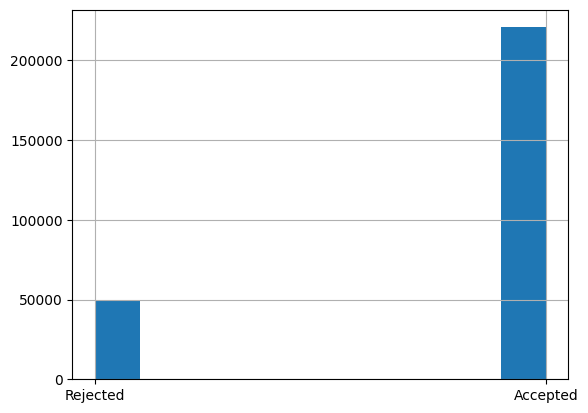

In [17]:
df['Status'].hist()

<Axes: >

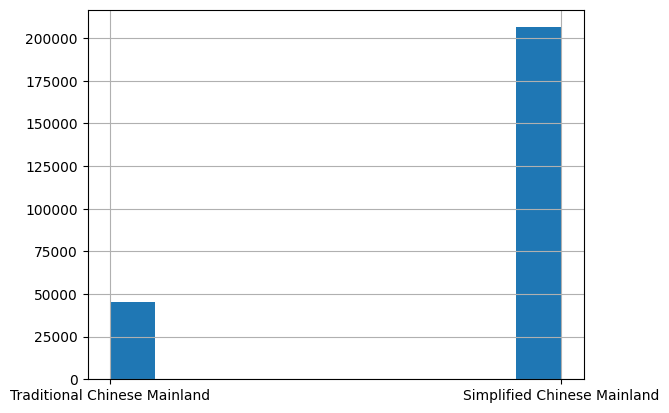

In [18]:
df['Language'].hist()

In [19]:
accepted_df = df[
    (df['Status'] == 'Accepted') & # verified examples
    (df['Language'] == 'Simplified Chinese Mainland') # simplified chars only
].reset_index()

len(accepted_df)

181532

In [20]:
accepted_df.groupby('Topics')['Sr No'].count().sort_values(ascending=False)

Topics
文教新闻Culture and Education     74977
其他新闻News                      65872
政治新闻Political                 14350
健康health                       6409
社会新闻Social                     5239
经济新闻Economic                   4966
军事新闻Military                   3802
法律新闻Legal                      1904
娱乐新闻Entertainment              1301
科技新闻Science and Technology      757
体育新闻Sports                      714
旅游Travel                        481
音乐Music                         474
时尚新闻Fashion                     157
健身Fitness                        80
美丽Beauty                         38
自助Self Help                      11
Name: Sr No, dtype: int64

In [21]:
accepted_df[accepted_df['Topics'] == 'News'].head()

,index,Sr No,Utterance,Status,Language,Topics,Unnamed: 5


## Preprocessing and Labelling

In [22]:
import re
def clean_text(text):
    # Remove all punctuation except spaces (optional)
    text = re.sub(r'[^\w\s]', '', text)
    # Optionally remove digits as well
    return text

In [23]:
clean_text(accepted_df.loc[0, 'Utterance'])

'他赢了布什说我很高兴是他赢了'

In [24]:
for sentence in accepted_df['Utterance']:
    clean_sentence = clean_text(sentence)
    predicted = predict_pinyin(clean_sentence, text2pinyin, char2idx, idx2pinyin, device)
    print(f"Input  : {clean_sentence}")
    print(f"Output : {' '.join(predicted)}")
    print()
    break

Input  : 他赢了布什说我很高兴是他赢了
Output : ta1 ying2 liao3 bu4 shen2 shuo1 wo3 hen3 gao1 xing1 shi4 ta1 ying2 le



In [25]:
from tqdm import tqdm

pinyin_labels = []
clean_sentences = []

for sentence in tqdm(accepted_df['Utterance']):
    clean_sentence = clean_text(sentence)
    predicted = predict_pinyin(clean_sentence, text2pinyin, char2idx, idx2pinyin, device)
    clean_sentences.append(clean_sentence)
    pinyin_labels.append(' '.join(predicted))

100%|██████████| 181532/181532 [39:11<00:00, 77.21it/s]


In [26]:
labelled_dataset = pd.DataFrame({
    'text': clean_sentences,
    'pinyin': pinyin_labels
})

In [27]:
labelled_dataset

,text,pinyin
0,他赢了布什说我很高兴是他赢了,ta1 ying2 liao3 bu4 shen2 shuo1 wo3 hen3 gao1 ...
1,你根本想不到有多畅销赛义德说,ni3 gen1 ben3 xiang3 bu4 dao4 you3 duo1 chang4...
2,国家主席是个虚职实权掌握在共产党总书记的手里,guo2 jia1 zhu3 xi2 shi4 ge4 xu1 zhi2 shi2 quan...
3,如果你批评以色列政府有些人会因此说你是反犹主义者,ru2 guo3 ni3 pi1 ping2 yi3 se4 lie4 zheng4 fu3...
4,我是16号下次请还要叫我啊,wo3 shi4 yu2 gu1 hao4 xia4 ci4 qing3 hai2 yao4...
...,...,...
181527,龙山小馆调酒师主管萨姆安德森,long2 shan1 xiao3 guan3 diao4 jiu3 shi1 zhu3 g...
181528,龙山水疗馆内的桑拿房,long2 shan1 shui3 liao2 guan3 nei4 de sang1 na...
181529,龙泉寺住持学诚法师2014年在北京人民大会堂,long2 quan2 si4 zhu4 chi2 xue2 cheng2 fa3 shi1...
181530,龙目岛距离巴厘岛不远,long2 mu4 dao3 ju4 li2 ba1 li2 dao3 bu4 yuan3


In [28]:
# Build character and pinyin vocabularies from the dataset

from tqdm import tqdm

def build_vocab(dataset):
    """
    dataset: list of dicts with keys 'text' (str) and 'pinyin' (str)
    returns:
        char2idx, idx2char, pinyin2idx, idx2pinyin
    """
    # Collect all characters and pinyin tokens
    chars = set()
    pinyins = set()
    
    for i, sample in tqdm(dataset.iterrows(), total=len(dataset)):
        text = sample['text']
        pinyin_str = sample['pinyin']
        
        # Add each character from text
        for ch in text:
            chars.add(ch)
        
        # Split pinyin by space and add each token
        tokens = pinyin_str.split()
        for tok in tokens:
            pinyins.add(tok)
    
    # Convert to sorted lists for deterministic order (optional)
    char_list = ['<UNK>', '<PAD>'] + sorted(chars)
    pinyin_list = ['<UNK>', '<PAD>'] + sorted(pinyins)
    
    # Create mappings
    char2idx = {ch: idx for idx, ch in enumerate(char_list)}
    idx2char = {idx: ch for idx, ch in enumerate(char_list)}
    
    pinyin2idx = {p: idx for idx, p in enumerate(pinyin_list)}
    idx2pinyin = {idx: p for idx, p in enumerate(pinyin_list)}
    
    print(f"Number of unique characters (including specials): {len(char_list)}")
    print(f"Number of unique pinyin tokens (including specials): {len(pinyin_list)}")

    return char2idx, idx2char, pinyin2idx, idx2pinyin

In [29]:
char2idx, idx2char, pinyin2idx, idx2pinyin = build_vocab(labelled_dataset)

100%|██████████| 181532/181532 [00:09<00:00, 19514.20it/s]

Number of unique characters (including specials): 5927
Number of unique pinyin tokens (including specials): 1078


In [30]:
labelled_dataset.to_csv("eval-chinese-short-sentences-pinyin.csv", index=False)